# Soft Computing Assignment – 2

# Motivation & Idea
Accoring to Jamali et al [3], there aren't many algorithms taking inspiration from plant behaviour. Rather a lot of Algorithms seem seek inspiration from the animal
In a number of plant species (e.g. cereals), the primary root system will dominate the early growth stages while the adventitious root system will dominate in older plants. In the latter case, the location and dynamic of the nodal root emissions are of prime importance for the general structure of the root system as has been demonstrated using cereals [1]

### References
- [1]: Hodge et al(2009): Plant root growth, architecture and function
- [2]: Dietrich(2018): Hydrotropism: how roots search for water
- [3]: Jamali et al(2025): A Systematic Review of Bio-Inspired Metaheuristic Optimization Algorithms: The Untapped Potential of Plant-Based Approaches 

<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.frontiersin.org%2Ffiles%2FArticles%2F1120583%2Ffpls-14-1120583-HTML-r1%2Fimage_m%2Ffpls-14-1120583-g001.jpg&f=1&nofb=1&ipt=9aa9c5732380295e1a45d7c84d4d9e22609925c30afd312e70ed91400f0747ed" alt="Description" width="300" height="200">

## Algorithm

```txt
Each root agent has:

position
energy
growth direction
personal best

At each iteration:

Each root senses:
local fitness-derived moisture gradient
gravity bias
local competition repulsion
random exploratory perturbation
It grows one step in the normalized weighted sum direction.
It evaluates the new position:
if fitness improved, energy increases
otherwise energy decreases by growth cost
If energy exceeds a threshold:
the root branches into children
children inherit partial energy and slightly diverging directions
If energy falls to zero:
the root dies
Roots update the shared moisture field:
promising regions become wetter
occupied regions may be depleted
```

---


### Pseudo Code

```py
Initialize dynamic moisture field M
Initialize a few root agents at random positions
For each root:
    evaluate objective
    set personal best
    set initial energy

while at least one root is alive:
    new_roots = []

    for each alive root:
        sense local moisture bias
        sense repulsion from nearby roots
        sample random exploration direction
        combine influences into growth direction

        propose new position
        apply boundary handling
        evaluate objective at new position

        improvement = old_fitness - new_fitness
        energy += reward_from(improvement) - movement_cost

        if improvement > 0:
            deposit moisture around new position

        deplete moisture at current position
        update personal best

        if energy <= 0:
            mark dead
        elif energy >= split_threshold and population < max_root_count:
            create child roots in nearby perturbed directions
            share energy between parent and children
            append children to new_roots

    add new_roots to population

return best personal best among all roots
```

# The "Anti-Derivative" Proof
A section explicitly stating how this algorithm differs fundamentally from PSO, ACO, and GA in its logic (e.g., different neighborhood structure or movement physics).

# Expolation vs Exploitation
A specific analysis of how the algorithm avoids local optima (diversification) and how it homes in on the global best (intensification).

# Benchmarking & Analysis

In this section the algorithm is tested on Rastrigin, Ackley, Schwefel and Rosenbrock function.

The result shows that the algorithm demonstrably works, shows meaningful convergence on multiple standard benchmarks, and performs especially well on Ackley and Rosenbrock, but still struggles on highly multimodal landscapes like Rastrigin and to a lesser extent Schwefel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
# Benchmark functions

def rastrigin(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

def ackley(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2.0 * np.pi * x))
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
    term2 = -np.exp(sum_cos / n)
    return float(term1 + term2 + 20.0 + np.e)

def schwefel(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

def rosenbrock(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

def compute_step_size(bounds, scale=0.05):
        bounds_arr = np.asarray(bounds, dtype=float)
        widths = bounds_arr[:, 1] - bounds_arr[:, 0]
        return scale * float(np.mean(widths))

def func_dict(name):
    if name == "rastrigin":
        return rastrigin
    elif name == "ackley":
        return ackley
    elif name == "schwefel":
        return schwefel
    elif name == "rosenbrock":
        return rosenbrock
    else:
        raise ValueError("Unknown function")

In [3]:
# Parameters

dimension = 3
population = 60
iterations = 200
runs = 10

test_cases = {
    "rastrigin": {
        "func": func_dict("rastrigin"),
        "bounds": (-5.12, 5.12),
    },
    "ackley": {
        "func": func_dict("ackley"),
        "bounds": (-32.768, 32.768),
    },
    "schwefel": {
        "func": func_dict("schwefel"),
        "bounds": (-500.0, 500.0),
    },
    "rosenbrock": {
        "func": func_dict("rosenbrock"),
        "bounds": (-2.048, 2.048),
    },
}

In [4]:
def normalize_bounds(bounds, dimension):
    """
    Returns:
        scalar_bounds: (low, high)
        vector_bounds: [(low, high), ...] length=dimension
        widths: np.ndarray of per-dimension widths
    """
    # case: (-5.12, 5.12)
    if isinstance(bounds[0], (int, float)):
        low, high = bounds
        scalar_bounds = (float(low), float(high))
        vector_bounds = [scalar_bounds] * dimension
    else:
        # case: [(-5.12, 5.12), ..., (-5.12, 5.12)]
        vector_bounds = [tuple(map(float, b)) for b in bounds]
        scalar_bounds = vector_bounds[0]

    widths = np.array([hi - lo for lo, hi in vector_bounds], dtype=float)
    return scalar_bounds, vector_bounds, widths


def run_benchmark(
    optimizer_cls,
    test_cases,
    optimizer_params=None,
    dimension=3,
    iterations=200,
    runs=10,
    seed_each_run=True,
    plot=True,
    plant_step_scale=0.05,
    plant_child_offset_scale=0.5,
):
    if optimizer_params is None:
        optimizer_params = {}

    results = {}

    if plot:
        plt.figure(figsize=(12, 6))

    if isinstance(test_cases, dict):
        cases_iter = [
            (name, case["func"], case["bounds"])
            for name, case in test_cases.items()
        ]
    else:
        cases_iter = test_cases

    for func_name, objective_function, bounds in cases_iter:
        print(f"\nRunning {func_name} benchmark ({runs} runs)")

        scalar_bounds, vector_bounds, widths = normalize_bounds(bounds, dimension)
        mean_width = float(np.mean(widths))

        all_histories = []
        final_scores = []
        final_positions = []
        times = []

        for run in range(runs):
            if seed_each_run:
                np.random.seed(run)

            start_time = time.time()
            params = dict(optimizer_params)

            # Common parameters
            params["objective_function"] = objective_function

            cls_name = optimizer_cls.__name__

            if cls_name == "PlantAlgorithm":
                # PlantAlgorithm expects per-dimension bounds
                params["bounds"] = vector_bounds

                # Auto-scale bound-dependent parameters if not explicitly given
                params["step_size"] = params.get("step_size", plant_step_scale * mean_width)
                params["child_offset"] = params.get(
                    "child_offset",
                    plant_child_offset_scale * params["step_size"]
                )

                # Optional: adapt gravity vector to dimension if not provided
                params["gravity_vector"] = np.asarray(
                    params.get("gravity_vector", np.zeros(dimension)),
                    dtype=float
                )

                params["seed"] = run

                optimizer = optimizer_cls(**params)
                best_position, best_fitness = optimizer.run(max_iterations=iterations)

            elif cls_name == "ArtificialBeeColony":
                # ABC usually expects scalar bounds + num_dimensions
                params["bounds"] = scalar_bounds
                params.setdefault("num_dimensions", dimension)
                params.setdefault("max_iterations", iterations)

                optimizer = optimizer_cls(**params)
                best_position, best_fitness = optimizer.run(max_iterations=iterations)

            elif cls_name == "Swarm":
                # Adjust this branch if your Swarm constructor differs
                params["bounds"] = scalar_bounds
                params.setdefault("dimension", dimension)
                params.setdefault("pop_size", params.pop("pop_size", 60))

                optimizer = optimizer_cls(**params)
                best_position, best_fitness = optimizer.run(
                    objective_function=objective_function,
                    iterations=iterations
                )

            else:
                # Generic fallback
                params["bounds"] = scalar_bounds
                params.setdefault("num_dimensions", dimension)

                optimizer = optimizer_cls(**params)
                best_position, best_fitness = optimizer.run(max_iterations=iterations)

            history = np.asarray(getattr(optimizer, "history", [best_fitness]), dtype=float)
            elapsed = time.time() - start_time

            all_histories.append(history)
            final_scores.append(best_fitness)
            final_positions.append(best_position)
            times.append(elapsed)

        max_len = max(len(h) for h in all_histories)
        padded_histories = []

        for h in all_histories:
            if len(h) < max_len:
                h = np.pad(h, (0, max_len - len(h)), mode="edge")
            padded_histories.append(h)

        all_histories = np.array(padded_histories)
        final_scores = np.array(final_scores, dtype=float)
        final_positions = np.array(final_positions, dtype=float)
        times = np.array(times, dtype=float)

        mean_curve = np.mean(all_histories, axis=0)
        mean_score = np.mean(final_scores)
        std_score = np.std(final_scores)
        mean_time = np.mean(times)
        mean_position = np.mean(final_positions, axis=0)

        print(f"\n{func_name} Summary")
        print(f"  Mean Best Score   : {mean_score:.6e} ± {std_score:.2e}")
        print(f"  Mean Best Position: {np.round(mean_position, 4)}")
        print(f"  Mean Time         : {mean_time:.4f} sec")

        results[func_name] = {
            "mean_curve": mean_curve,
            "mean_score": mean_score,
            "std_score": std_score,
            "mean_time": mean_time,
            "mean_position": mean_position,
            "all_scores": final_scores,
            "all_positions": final_positions,
            "all_times": times,
            "all_histories": all_histories,
        }

        if plot:
            plt.plot(np.maximum(mean_curve, 1e-12), label=f"{func_name} (mean)")

    if plot:
        plt.title(f"Benchmark Convergence Curve (Dim = {dimension})")
        plt.xlabel("Iterations")
        plt.ylabel("Best Fitness (Log Scale)")
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return results


Running rastrigin benchmark (10 runs)

rastrigin Summary
  Mean Best Score   : 8.809073e+00 ± 5.30e+00
  Mean Best Position: [ 0.3148 -0.3936 -0.1942]
  Mean Time         : 9.9154 sec

Running ackley benchmark (10 runs)

ackley Summary
  Mean Best Score   : 1.447610e+00 ± 5.03e-01
  Mean Best Position: [-0.0581  0.0786  0.0504]
  Mean Time         : 9.0226 sec

Running schwefel benchmark (10 runs)

schwefel Summary
  Mean Best Score   : 2.633221e+02 ± 7.53e+01
  Mean Best Position: [-34.2472 127.0578 144.855 ]
  Mean Time         : 9.9855 sec

Running rosenbrock benchmark (10 runs)

rosenbrock Summary
  Mean Best Score   : 4.027492e-01 ± 4.08e-01
  Mean Best Position: [0.8072 0.7257 0.6481]
  Mean Time         : 12.5111 sec


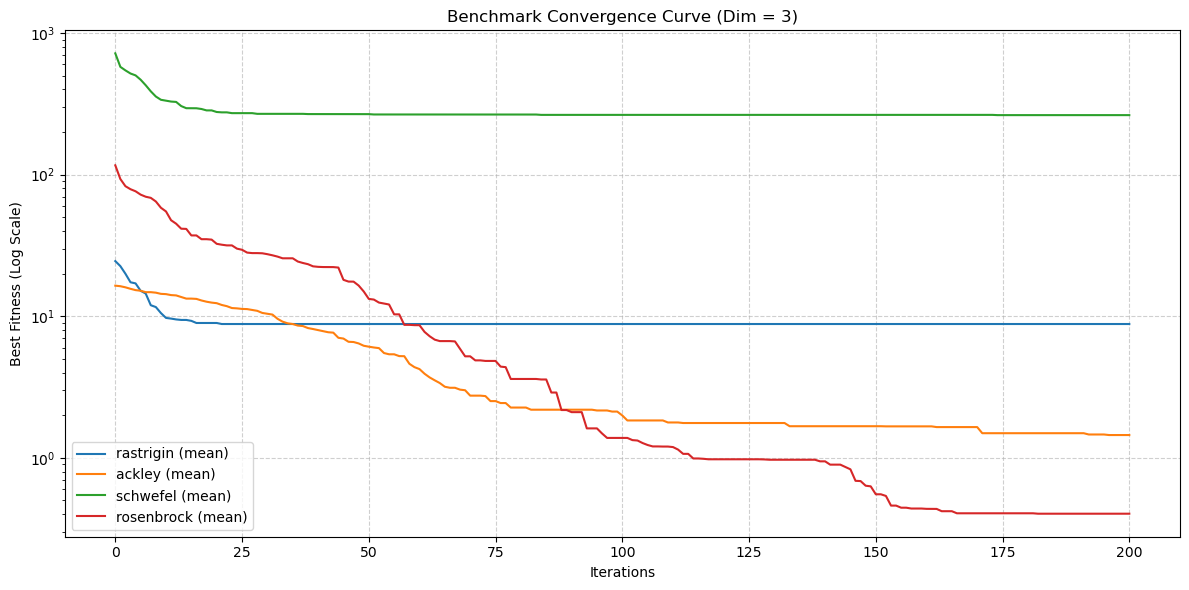

In [30]:
from RootAlgorithm import PlantAlgorithm

results_plant = run_benchmark(
    optimizer_cls=PlantAlgorithm,
    test_cases=test_cases,
    optimizer_params={
        "max_root_count": population,
        "initial_energy": 6.0,
        "step_cost": 0.03,
        "splitting_threshold": 8.0,
        "max_children": 2,
        "alpha": 12.0,
        "deposit_scale": 2.5,
        "depletion_scale": 0.02,
        "weights": (1.8, 0.0, 0.4, 0.3),
        "repulsion_radius": 1.8,
        "gravity_vector": np.zeros(dimension),
        "personal_best_weight": 0.8,
        "moisture_sigma": 0.4,
        "moisture_base": 0.01,
        "evaporation_rate": 0.005,
        "split_ratio": 0.6,
        "initial_root_count": 12,
    },
    dimension=dimension,
    iterations=iterations,
    runs=runs,
    plant_step_scale=0.05,          # step_size = 5% of average search width
    plant_child_offset_scale=0.5,   # child_offset = 0.5 * step_size
)

# PSO and ABC

Comparing the algorithm against ABC and PSO the first thing we notice is that computational demand for the plant algorithm is quite high. Running the program with the same functions and iterations resulted in much longer wait time than ABC and PSO combined. Both of which ran in a few seconds while our algorithm took over a minute.

Overall the best performing algorithm in the test was the ABC algorithm, second came PSO algorithm while our algorithm performed the worst.


Running rastrigin benchmark (10 runs)

rastrigin Summary
  Mean Best Score   : 0.000000e+00 ± 0.00e+00
  Mean Best Position: [ 0. -0. -0.]
  Mean Time         : 1.7283 sec

Running ackley benchmark (10 runs)

ackley Summary
  Mean Best Score   : 3.641532e-15 ± 1.91e-15
  Mean Best Position: [0. 0. 0.]
  Mean Time         : 1.9826 sec

Running schwefel benchmark (10 runs)

schwefel Summary
  Mean Best Score   : 3.818270e-05 ± 1.61e-12
  Mean Best Position: [420.9687 420.9687 420.9687]
  Mean Time         : 1.6280 sec

Running rosenbrock benchmark (10 runs)

rosenbrock Summary
  Mean Best Score   : 9.902276e-03 ± 1.05e-02
  Mean Best Position: [1.0012 1.0012 1.0057]
  Mean Time         : 1.7990 sec


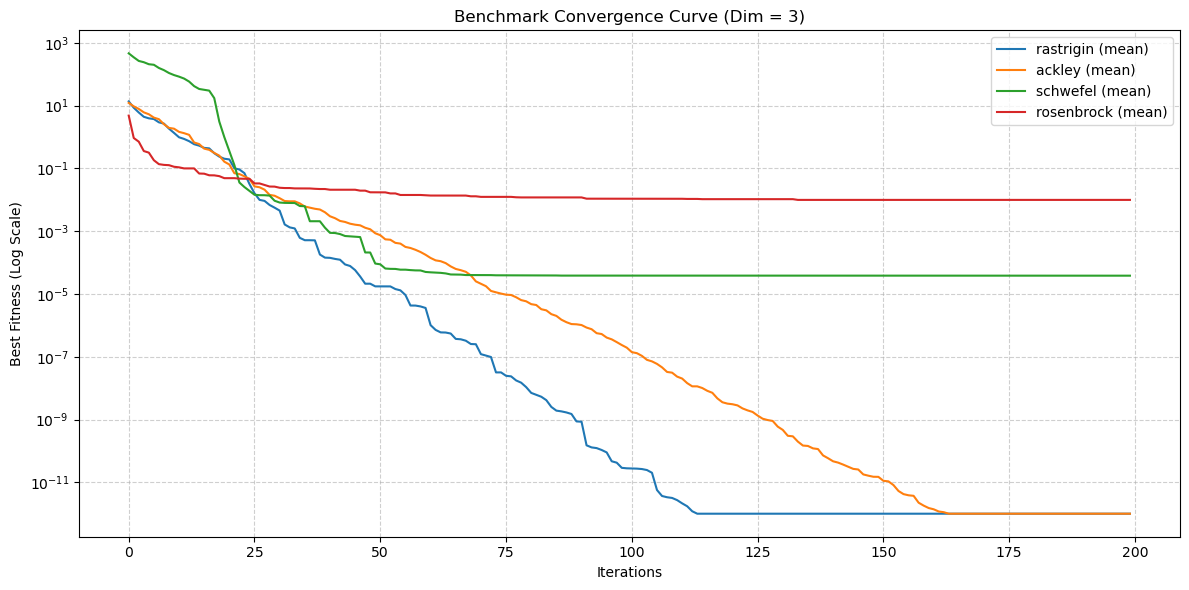

In [31]:
from ABCAlgorithm import ArtificialBeeColony

results_abc = run_benchmark(
    optimizer_cls=ArtificialBeeColony,
    test_cases=test_cases,
    optimizer_params={
        "num_food_sources": population,
        "limit": (population * dimension) // 2,
    },
    dimension=dimension,
    iterations=iterations,
    runs=runs,
)


Running rastrigin benchmark (10 runs)

rastrigin Summary
  Mean Best Score   : 9.949591e-02 ± 2.98e-01
  Mean Best Position: [ 0.     -0.      0.0995]
  Mean Time         : 0.3669 sec

Running ackley benchmark (10 runs)

ackley Summary
  Mean Best Score   : 4.298784e-14 ± 1.15e-13
  Mean Best Position: [ 0.  0. -0.]
  Mean Time         : 0.3614 sec

Running schwefel benchmark (10 runs)

schwefel Summary
  Mean Best Score   : 1.989918e-01 ± 3.98e-01
  Mean Best Position: [-0.      0.0995  0.0995]
  Mean Time         : 0.3661 sec

Running rosenbrock benchmark (10 runs)

rosenbrock Summary
  Mean Best Score   : 2.984877e-01 ± 4.56e-01
  Mean Best Position: [ 0.0995 -0.0995 -0.0995]
  Mean Time         : 0.3632 sec


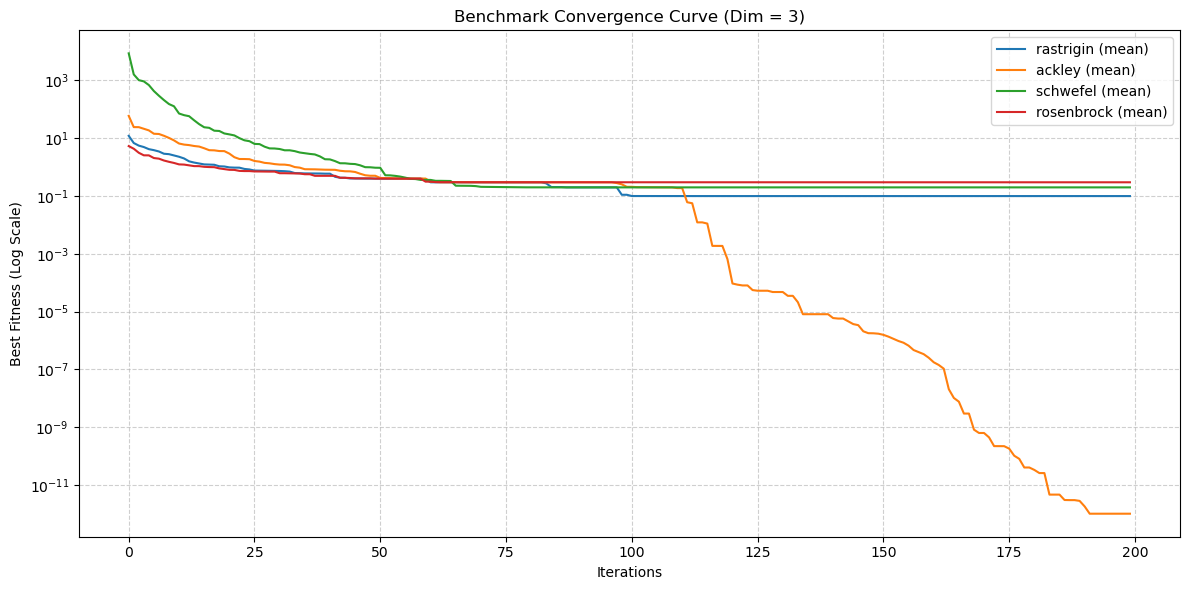

In [5]:

from PSOAlgorithm import Swarm

results = run_benchmark(
    optimizer_cls=Swarm,
    test_cases=test_cases,
    dimension=dimension,
    iterations=iterations,
    runs=runs,
    optimizer_params={
        "pop_size": population,
        "dimension": dimension
    }
)

# Additional Experimentations

## Hyperparameter Optimization Test

The developed algorithm is stochastic and has a few parameters to adjust that can influence the result of the algorithm.
Below is a randomized grid search setup. It samples parameter combinations, runs multiple seeds on the 4 benchmark functions, and ranks configurations by mean normalized score.

We noticed that changing weights can have significance on the performance of the algorithm. Instrestingly, Overreliance on the moisture gradient results in bad performance. Weighing in the other factors does seem to benefit the algorithm.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Any, Sequence
import csv
import json
import math
import random
import numpy as np


# ------------------------------------------------------------
# Benchmark functions
# ------------------------------------------------------------

def rastrigin(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return 10.0 * n + np.sum(x * x - 10.0 * np.cos(2.0 * np.pi * x))


def ackley(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    s1 = np.sum(x * x)
    s2 = np.sum(np.cos(2.0 * np.pi * x))
    return (
        -20.0 * np.exp(-0.2 * np.sqrt(s1 / n))
        - np.exp(s2 / n)
        + 20.0
        + math.e
    )


def schwefel(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return 418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x))))


def rosenbrock(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2)


# ------------------------------------------------------------
# Benchmark problem definitions
# ------------------------------------------------------------

@dataclass
class BenchmarkProblem:
    name: str
    func: Callable[[np.ndarray], float]
    bounds: Sequence[Tuple[float, float]]
    optimum: float = 0.0


def make_problems(dimension: int = 3) -> List[BenchmarkProblem]:
    return [
        BenchmarkProblem("Rastrigin", rastrigin, [(-5.12, 5.12)] * dimension, 0.0),
        BenchmarkProblem("Ackley", ackley, [(-32.768, 32.768)] * dimension, 0.0),
        BenchmarkProblem("Schwefel", schwefel, [(-500.0, 500.0)] * dimension, 0.0),
        BenchmarkProblem("Rosenbrock", rosenbrock, [(-5.0, 10.0)] * dimension, 0.0),
    ]


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def sample_param_config(
    rng: random.Random,
    search_space: Dict[str, Sequence[Any]],
) -> Dict[str, Any]:
    return {k: rng.choice(list(v)) for k, v in search_space.items()}


def stable_normalized_score(
    value: float,
    optimum: float = 0.0,
    eps: float = 1e-12,
) -> float:
    return abs(value - optimum) / max(abs(optimum), 1.0, eps)


def mean_std(values: Sequence[float]) -> Tuple[float, float]:
    arr = np.asarray(values, dtype=float)
    return float(np.mean(arr)), float(np.std(arr))


def serialize_value(v: Any) -> Any:
    if isinstance(v, np.ndarray):
        return v.tolist()
    if isinstance(v, tuple):
        return list(v)
    return v


# ------------------------------------------------------------
# Core evaluation
# ------------------------------------------------------------

def evaluate_config(
    config: Dict[str, Any],
    problems: Sequence[BenchmarkProblem],
    seeds: Sequence[int],
    max_iterations: int = 1200,
) -> Dict[str, Any]:
    """
    Requires PlantAlgorithm to already be defined/imported.
    """
    per_problem: Dict[str, Dict[str, Any]] = {}
    aggregate_scores: List[float] = []

    for problem in problems:
        fitnesses: List[float] = []
        positions: List[np.ndarray] = []

        for seed in seeds:
            algo = PlantAlgorithm(
                objective_function=problem.func,
                bounds=problem.bounds,
                max_root_count=config["max_root_count"],
                initial_energy=config["initial_energy"],
                step_size=config["step_size"],
                step_cost=config["step_cost"],
                splitting_threshold=config["splitting_threshold"],
                max_children=config["max_children"],
                alpha=config["alpha"],
                deposit_scale=config["deposit_scale"],
                depletion_scale=config["depletion_scale"],
                weights=config["weights"],
                repulsion_radius=config["repulsion_radius"],
                gravity_vector=np.array(config["gravity_vector"], dtype=float),
                personal_best_weight=config["personal_best_weight"],
                moisture_sigma=config["moisture_sigma"],
                moisture_base=config["moisture_base"],
                evaporation_rate=config["evaporation_rate"],
                split_ratio=config["split_ratio"],
                child_offset=config["child_offset"],
                initial_root_count=config["initial_root_count"],
                seed=seed,
            )

            best_pos, best_fit = algo.run(max_iterations=max_iterations)
            fitnesses.append(float(best_fit))
            positions.append(best_pos)

        mean_fit, std_fit = mean_std(fitnesses)
        best_run_idx = int(np.argmin(fitnesses))
        best_fit = float(fitnesses[best_run_idx])
        best_pos = positions[best_run_idx]

        score = stable_normalized_score(mean_fit, optimum=problem.optimum)
        aggregate_scores.append(score)

        per_problem[problem.name] = {
            "mean_fitness": mean_fit,
            "std_fitness": std_fit,
            "best_fitness": best_fit,
            "best_position": best_pos.tolist(),
            "all_fitnesses": [float(x) for x in fitnesses],
            "score": score,
        }

    overall_score = float(np.mean(aggregate_scores))

    return {
        "config": {k: serialize_value(v) for k, v in config.items()},
        "overall_score": overall_score,
        "per_problem": per_problem,
    }


# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

def flatten_result_for_csv(result: Dict[str, Any]) -> Dict[str, Any]:
    row: Dict[str, Any] = {}

    row["overall_score"] = result["overall_score"]

    for k, v in result["config"].items():
        if isinstance(v, (list, dict)):
            row[f"param_{k}"] = json.dumps(v)
        else:
            row[f"param_{k}"] = v

    for problem_name, metrics in result["per_problem"].items():
        prefix = problem_name.lower()
        row[f"{prefix}_mean_fitness"] = metrics["mean_fitness"]
        row[f"{prefix}_std_fitness"] = metrics["std_fitness"]
        row[f"{prefix}_best_fitness"] = metrics["best_fitness"]
        row[f"{prefix}_best_position"] = json.dumps(metrics["best_position"])
        row[f"{prefix}_all_fitnesses"] = json.dumps(metrics["all_fitnesses"])
        row[f"{prefix}_score"] = metrics["score"]

    return row


def write_results_csv(results: List[Dict[str, Any]], filepath: str) -> None:
    rows = [flatten_result_for_csv(r) for r in results]
    if not rows:
        return

    fieldnames: List[str] = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_best_config_json(result: Dict[str, Any], filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)


# ------------------------------------------------------------
# Random search
# ------------------------------------------------------------

def random_grid_search_with_logs(
    search_space: Dict[str, Sequence[Any]],
    problems: Sequence[BenchmarkProblem],
    n_samples: int = 40,
    seeds_per_config: Sequence[int] = (0, 1, 2),
    max_iterations: int = 1200,
    random_state: int = 123,
    top_k: int = 10,
    all_results_csv: str = "all_results.csv",
    top_results_csv: str = "top_results.csv",
    best_config_json: str = "best_config.json",
) -> List[Dict[str, Any]]:
    rng = random.Random(random_state)
    seen = set()
    all_results: List[Dict[str, Any]] = []

    max_unique = 1
    for values in search_space.values():
        max_unique *= len(values)

    actual_samples = min(n_samples, max_unique)

    while len(all_results) < actual_samples:
        config = sample_param_config(rng, search_space)

        key = tuple(
            (k, tuple(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
            for k, v in sorted(config.items(), key=lambda item: item[0])
        )
        if key in seen:
            continue
        seen.add(key)

        result = evaluate_config(
            config=config,
            problems=problems,
            seeds=seeds_per_config,
            max_iterations=max_iterations,
        )
        all_results.append(result)

        write_results_csv(all_results, all_results_csv)

        print(
            f"[{len(all_results)}/{actual_samples}] "
            f"score={result['overall_score']:.6f}"
        )

    all_results.sort(key=lambda r: r["overall_score"])
    top_results = all_results[:top_k]

    write_results_csv(all_results, all_results_csv)
    write_results_csv(top_results, top_results_csv)
    write_best_config_json(top_results[0], best_config_json)

    return top_results


# ------------------------------------------------------------
# Search space
# ------------------------------------------------------------

def make_search_space(dimension: int = 3) -> Dict[str, Sequence[Any]]:
    zero_gravity = tuple([0.0] * dimension)

    return {
        "max_root_count": [40, 60, 80],
        "initial_energy": [4.0, 6.0, 8.0, 10.0],
        "step_size": [0.04, 0.08, 0.12, 0.18, 0.25],
        "step_cost": [0.01, 0.02, 0.03, 0.05],
        "splitting_threshold": [4.0, 5.0, 6.0, 8.0],
        "max_children": [1, 2, 3],
        "alpha": [2.0, 4.0, 8.0, 12.0],
        "deposit_scale": [0.5, 1.0, 2.0, 4.0, 8.0],
        "depletion_scale": [0.005, 0.01, 0.03, 0.05, 0.08],
        "weights": [
            (1.0, 0.0, 0.10, 0.20),
            (1.4, 0.0, 0.15, 0.30),
            (1.8, 0.0, 0.25, 0.45),
            (2.2, 0.0, 0.10, 0.60),
            (2.5, 0.0, 0.05, 0.80),
        ],
        "repulsion_radius": [0.4, 0.8, 1.2, 1.8],
        "gravity_vector": [zero_gravity],
        "personal_best_weight": [0.4, 0.8, 1.2, 1.8, 2.5],
        "moisture_sigma": [0.4, 0.7, 0.9, 1.2, 1.8],
        "moisture_base": [0.001, 0.01, 0.05, 0.1],
        "evaporation_rate": [0.001, 0.005, 0.01, 0.03, 0.05],
        "split_ratio": [0.25, 0.45, 0.60],
        "child_offset": [0.02, 0.06, 0.12, 0.20],
        "initial_root_count": [4, 8, 12],
    }


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

if __name__ == "__main__":
    # from your_algorithm_file import PlantAlgorithm

    DIMENSION = 3
    MAX_ITERATIONS = 100
    N_SAMPLES = 10
    SEEDS_PER_CONFIG = [0, 1, 2, 3, 4]

    problems = make_problems(dimension=DIMENSION)
    search_space = make_search_space(dimension=DIMENSION)

    top_results = random_grid_search_with_logs(
        search_space=search_space,
        problems=problems,
        n_samples=N_SAMPLES,
        seeds_per_config=SEEDS_PER_CONFIG,
        max_iterations=MAX_ITERATIONS,
        random_state=42,
        top_k=5,
        all_results_csv="all_results.csv",
        top_results_csv="top_results.csv",
        best_config_json="best_config.json",
    )

    print("\nTop 5 configurations:")
    for i, result in enumerate(top_results, start=1):
        print(f"Rank #{i}: score={result['overall_score']:.6f}")
        print(result["config"])